# Generalization Tests
1. Environmental on self data

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import json
from sklearn.model_selection import KFold, train_test_split
from keras.optimizers import Adam
from keras.models import Model, load_model
from keras.layers import Dense, Input, Flatten, Conv3D, BatchNormalization, Dropout, Conv2D
from keras.callbacks import EarlyStopping
from datetime import datetime

# main_results is used
# r_results : repeatability
MODEL_TEMPORAL = 'temporal'
MODEL_BASE = 'base'
EXP_FORMATTED_PATH = os.path.join("..", "dataset_main", "expformatted")
KINECT_PATH = os.path.join(EXP_FORMATTED_PATH, "kinect")
MMWAVE_PATH = os.path.join(EXP_FORMATTED_PATH, "mmWave")
MARS_PATH = os.path.join(EXP_FORMATTED_PATH, "mars")
RESULT_PATH = os.path.join("..", "main_results")
NUM_KEYPOINTS = 57
BATCH_SIZE = 128
EPOCHS = 150
MODEL_PATH = os.path.join("..", "model", "main_tests")

In [38]:
def define_baseline_mars(in_shape, n_keypoints):

    in_one = Input(shape=in_shape)
    conv_one_1 = Conv2D(
        16, kernel_size=(3, 3), activation="relu", strides=(1, 1), padding="same"
    )(in_one)
    conv_one_1 = Dropout(0.3)(conv_one_1)
    conv_one_2 = Conv2D(
        32, kernel_size=(3, 3), activation="relu", strides=(1, 1), padding="same"
    )(conv_one_1)
    conv_one_2 = Dropout(0.3)(conv_one_2)

    conv_one_2 = BatchNormalization(momentum=0.95)(conv_one_2)

    fe = Flatten()(conv_one_2)
    # dense1
    dense_layer1 = Dense(512, activation="relu")(fe)
    dense_layer1 = BatchNormalization(momentum=0.95)(dense_layer1)
    # # dropout

    # dropout
    dense_layer1 = Dropout(0.4)(dense_layer1)

    out_layer = Dense(n_keypoints, activation="linear")(dense_layer1)

    # model
    model = Model(in_one, out_layer)
    opt = Adam(learning_rate=0.001, beta_1=0.5)

    # compile the model
    model.compile(
        loss="mae",
        optimizer=opt,
        metrics=["mae", "mse", "mape", tf.keras.metrics.RootMeanSquaredError()],
    )
    return model


def define_temporal_MARS(in_shape, n_keypoints):
    in_one = Input(shape=in_shape)
    conv_one_1 = Conv3D(
        16, kernel_size=(3, 3, 3), activation="relu", strides=(1, 1, 1), padding="same"
    )(in_one)
    conv_one_1 = Dropout(0.3)(conv_one_1)
    conv_one_2 = Conv3D(
        32, kernel_size=(3, 3, 3), activation="relu", strides=(1, 1, 1), padding="same"
    )(conv_one_1)
    conv_one_2 = Dropout(0.3)(conv_one_2)

    conv_one_2 = BatchNormalization(momentum=0.95)(conv_one_2)

    fe = Flatten()(conv_one_2)
    # dense1
    dense_layer1 = Dense(3 * 512, activation="relu")(fe)
    dense_layer1 = BatchNormalization(momentum=0.95)(dense_layer1)
    # # dropout

    # dropout
    dense_layer1 = Dropout(0.4)(dense_layer1)

    out_layer = Dense(n_keypoints, activation="linear")(dense_layer1)

    # model
    model = Model(in_one, out_layer)
    opt = Adam(learning_rate=0.001, beta_1=0.5)

    # compile the model
    model.compile(
        loss="mse",
        optimizer=opt,
        metrics=["mae", "mse", "mape", tf.keras.metrics.RootMeanSquaredError()],
    )
    return model

def predict_eval(predicted, groundtruth):
   print(f"shape: {predicted.shape} {groundtruth.shape}")
   # Reshape to (n, 19, 3)
   pred_reshaped = predicted.reshape(-1, 19, 3)
   gt_reshaped = groundtruth.reshape(-1, 19, 3)
   
   # ---------- 1. Overall MAE ----------
   abs_error = np.abs(pred_reshaped - gt_reshaped)
   overall_mae = np.mean(abs_error)

   # ---------- 2. Joint-wise MAE ----------
   # Average over samples and coordinates per joint
   jointwise_mae = np.mean(abs_error, axis=(0, 2))  # shape: (19,)
   
   # ---------- 3. Overall Euclidean Distance (MPJPE) ----------
   euclidean_dist = np.linalg.norm(pred_reshaped - gt_reshaped, axis=2)  # shape: (n, 19)
   overall_euclidean_error = np.mean(euclidean_dist)

   # ---------- 4. Joint-wise Euclidean Distance ----------
   jointwise_euclidean_error = np.mean(euclidean_dist, axis=0)  # shape: (19,)

   return {
      "mae": overall_mae,
      "joint_mae": jointwise_mae.tolist(),
      "euc": overall_euclidean_error,
      "joint_euc": jointwise_euclidean_error.tolist()
   }


def load_json(filename):
    data = None
    with open(filename, "r") as f:
        data = json.loads(f.read())
    return data


def load_dataset(dataset):
    mmwave_data = []
    kinect_data = []
    mars_data = []
    
    # TODO: Check for G1
    if 'CBCA' in dataset:
        dataset.append('G1')

    for experiment in dataset:
        mmw = np.load(os.path.join(MMWAVE_PATH, f"{experiment}.npy"))
        mmwave_data.append(mmw)
        kin = np.load(os.path.join(KINECT_PATH, f"{experiment}.npy"))
        kinect_data.append(kin)
        mars = np.load(os.path.join(MARS_PATH, f"{experiment}.npy"))
        mars_data.append(mars)
    return np.concatenate(mmwave_data, axis=0), \
        np.concatenate(kinect_data, axis=0), \
        np.concatenate(mars_data, axis=0)


early_stop = EarlyStopping(
    monitor="val_loss", 
    patience=6,
    restore_best_weights=True,
    verbose=1
)

def run_model(model, train_features, train_labels, testname):
    x_train, x_val, y_train, y_val = train_test_split(
        train_features, train_labels, test_size=0.25, random_state=888, shuffle = True
    )
    history = model.fit(
        x_train,
        y_train,
        batch_size = BATCH_SIZE,
        epochs = EPOCHS,
        # verbose=1,
        validation_data=(x_val, y_val),
        callbacks=[early_stop]
    )
    model.save(os.path.join(MODEL_PATH, f"{testname}.h5"), True)
    score_train = model.evaluate(x_train, y_train, verbose=0)
    score_val = model.evaluate(x_val, y_val, verbose=0)
    return score_train, score_val, history

In [32]:
def extract_result(history, train_score, val_score):
    print(history.history)
    return {
        "training_loss": history.history['loss'],
        "validation_loss": history.history['val_loss'],
        "training_accuracy": history.history['mae'],
        "validation_accuracy": history.history['val_mae'],
        "validation_mae": val_score[1],
        "train_mae": train_score[1]
    }

def run_experiment(exp):
    print(f"Running {exp}")
    experiment_splits = load_json("generalisation_test_splits.json")
    mmwave_train, kinect_train, mars_train = load_dataset(experiment_splits[exp]['train'])

    print(f"Training Temporal {mmwave_train.shape} {kinect_train.shape}")
    tmars_model = define_temporal_MARS(mmwave_train[0].shape, NUM_KEYPOINTS)
    tmars_score_train, tmars_score_val , tmars_history= run_model(tmars_model, mmwave_train, kinect_train, f"tmars_{exp}")
    
    print(f"Training Base {mars_train.shape}")
    bmars_model = define_baseline_mars(mars_train[0].shape, NUM_KEYPOINTS)
    bmars_score_train, bmars_score_val , bmars_history= run_model(bmars_model, mars_train, kinect_train, f"bmars_{exp}")
    
    # Store results
    results = {}
    results['tmars'] = extract_result(tmars_history, tmars_score_train, tmars_score_val)
    results['bmars'] = extract_result(bmars_history, bmars_score_train, bmars_score_val)
    
    with open(os.path.join(RESULT_PATH, f"{exp}_training_result.json"), "w") as f:
        f.write(json.dumps(results))

    return results
    

# e2_result = run_experiment("E2")

In [34]:
e1_result = run_experiment("E1")
e2_result = run_experiment("E2")
e3_result = run_experiment("E3")
a1_result = run_experiment("A1")
a2_result = run_experiment("A2")
a3_result = run_experiment("A3")
d1_result = run_experiment("D1")
u1_result = run_experiment("U1")
u2_result = run_experiment("U2")
# e2_result = run_experiment("E2")

Running E1
Training Temporal (142557, 3, 8, 8, 5) (142557, 57)
Epoch 1/150
  2/836 [..............................] - ETA: 1:43 - loss: 3.7330 - mae: 1.4025 - mse: 3.7330 - mape: 70272624.0000 - root_mean_squared_error: 1.9321 

KeyboardInterrupt: 

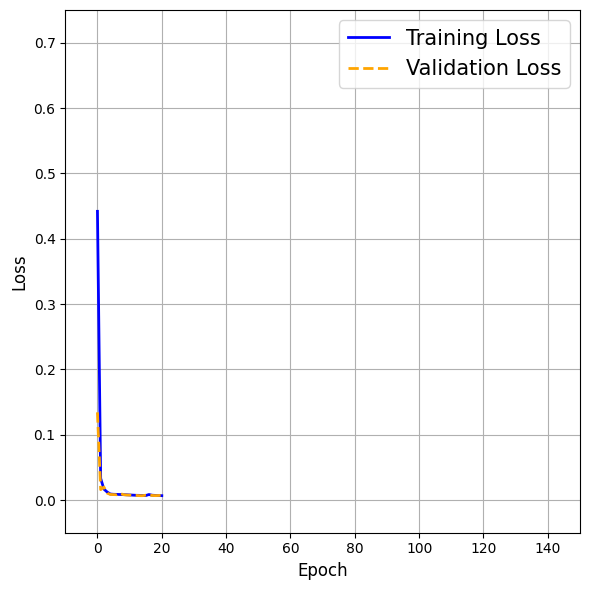

In [61]:
def plot_training_result(exp):
    result = load_json(os.path.join(RESULT_PATH, f"{exp}_training_result.json"))
    result = result['tmars']
    epochs = range(len(result['training_loss']))
    y_lim = 0.75
    x_lim = 150
    x_low = -10
    y_low = -0.05
    # Plot Results for Training loss, validation loss
    fig, (ax1) = plt.subplots(1, 1, figsize=(6, 6))

    # Subfigure 1: Loss
    ax1.plot(epochs, result['training_loss'], label='Training Loss', color='blue', linestyle='-', linewidth=2)
    ax1.plot(epochs, result['validation_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
    # ax1.set_title('Loss over Epochs')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_ylim((y_low, y_lim))
    ax1.set_xlim((x_low, x_lim))
    ax1.legend(fontsize=15)
    ax1.grid(True)

    # # # Subfigure 2: Accuracy
    # # ax2.plot(epochs, result['training_accuracy'], label='Training MAE', color='green', linestyle='-')
    # # ax2.plot(epochs, result['validation_accuracy'], label='Validation MAE', color='red', linestyle='--')
    # # ax2.set_title('MAE over Epochs')
    # # ax2.set_xlabel('Epoch')
    # # ax2.set_ylabel('MAE (m)')
    # # ax2.set_ylim((y_low, y_lim))
    # # ax2.set_xlim((x_low, x_lim))

    # ax2.legend()
    # ax2.grid(True)

    plt.tight_layout()
    plt.show()


plot_training_result("E1")


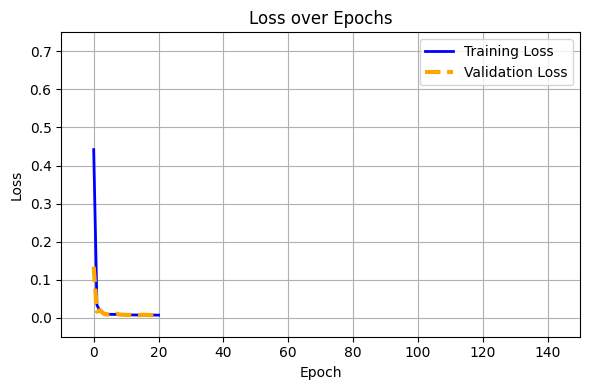

In [ ]:
# plot_training_result()

In [ ]:
# # Load the experiments from the data
# # import json

# experiment_splits = load_json("generalisation_test_splits.json")
# experiment_description = load_json("generalisation_test_desc.json")
# scores_tmars = []
# scores_bmars = []
# for exp in experiment_description:
#     print(f"Running {exp}")
#     mmwave_train, kinect_train, mars_train = load_dataset(experiment_splits[exp]['train'])
#     print(f"Training Temporal {mmwave_train.shape} {kinect_train.shape}")
#     tmars_model = define_temporal_MARS(mmwave_train[0].shape, NUM_KEYPOINTS)
#     tmars_score_train, tmars_score_val , tmars_history= run_model(tmars_model, mmwave_train, kinect_train, f"tmars_{exp}")
    
#     print(f"Training Base {mars_train.shape}")
#     bmars_model = define_baseline_mars(mars_train[0].shape, NUM_KEYPOINTS)
#     bmars_score_train, bmars_score_val , tmars_history= run_model(bmars_model, mars_train, kinect_train, f"bmars_{exp}")
    
#     scores_tmars.append(tmars_score_train)
#     scores_tmars.append(tmars_score_val)
#     scores_bmars.append(bmars_score_train)
#     scores_bmars.append(bmars_score_val)
    
#     # print(experiment_splits[exp]['train'])
#     # print(mmwave_train.shape)
#     break

Running E1
Training Temporal (142557, 3, 8, 8, 5) (142557, 57)
Epoch 1/150
836/836 [==============================] - 99s 118ms/step - loss: 0.3922 - mae: 0.3597 - mse: 0.3922 - mape: 17650098.0000 - root_mean_squared_error: 0.6262 - val_loss: 0.0313 - val_mae: 0.1125 - val_mse: 0.0313 - val_mape: 3827773.7500 - val_root_mean_squared_error: 0.1768
Epoch 2/150
836/836 [==============================] - 98s 118ms/step - loss: 0.0248 - mae: 0.1000 - mse: 0.0248 - mape: 3493456.7500 - root_mean_squared_error: 0.1575 - val_loss: 0.0151 - val_mae: 0.0677 - val_mse: 0.0151 - val_mape: 1717082.0000 - val_root_mean_squared_error: 0.1228
Epoch 3/150
836/836 [==============================] - 100s 119ms/step - loss: 0.0182 - mae: 0.0870 - mse: 0.0182 - mape: 2870197.7500 - root_mean_squared_error: 0.1350 - val_loss: 0.0198 - val_mae: 0.0871 - val_mse: 0.0198 - val_mape: 2889799.0000 - val_root_mean_squared_error: 0.1408
Epoch 4/150
836/836 [==============================] - 99s 119ms/step - loss:

: 

In [ ]:
ARM_JOINTS = [4,5,6, 8, 9, 10]


def perform_split(train_features, train_labels):
    _, train_val, _, label_val = train_test_split(
        train_features, train_labels, test_size=0.25, random_state=888, shuffle = True
    )
    return train_val, label_val

def extract_mae(result):
    return np.mean(np.array(result['joint_mae'])[ARM_JOINTS])

def calculate_generalisation_metric(train_mae, test_mae):
    return (test_mae - train_mae)/train_mae 

def format_result(g, test, train, train_mae, test_mae):
    return {"g":g, "test":test, "train": train, "train_mae": train_mae, "test_mae": test_mae}


def evaluate_experiment(exp):
    experiment_splits = load_json("generalisation_test_splits.json")
    mmwave_train, kinect_train, mars_train = load_dataset(experiment_splits[exp]['train'])
    mmwave_test, kinect_test, mars_test = load_dataset(experiment_splits[exp]['test'])

    # Perform the split of train & test
    mmwave_val, kinect_mmwave_val = perform_split(mmwave_train, kinect_train)
    mars_val, kinect_mars_val = perform_split(mars_train, kinect_train)



    tmars_model = load_model(os.path.join(MODEL_PATH, f"tmars_{exp}.h5"))
    bmars_model = load_model(os.path.join(MODEL_PATH, f"bmars_{exp}.h5"))

    print(f"Running {exp} tmars test ")
    tmars_test_predict = tmars_model.predict(mmwave_test)
    tmars_test_result = predict_eval(tmars_test_predict, kinect_test)
    
    print(f"Running {exp} tmars train ")
    tmars_train_predict = tmars_model.predict(mmwave_val)
    tmars_train_result = predict_eval(tmars_train_predict, kinect_mmwave_val)

    print(f"Running {exp} bmars test")
    bmars_test_predict = bmars_model.predict(mars_test)
    bmars_test_result = predict_eval(bmars_test_predict, kinect_test)

    print(f"Running {exp} bmars train")
    bmars_train_predict = bmars_model.predict(mars_val)
    bmars_train_result = predict_eval(bmars_train_predict, kinect_mars_val)

    tmars_train_mae = extract_mae(tmars_train_result)
    tmars_test_mae = extract_mae(tmars_test_result)

    bmars_train_mae = extract_mae(bmars_train_result)
    bmars_test_mae = extract_mae(bmars_test_result)

    tmars_g = calculate_generalisation_metric(tmars_train_mae, tmars_test_mae)
    bmars_g = calculate_generalisation_metric(bmars_train_mae, bmars_test_mae)

    result = {"tmars": format_result(tmars_g, tmars_test_result, tmars_train_result, tmars_train_mae, tmars_test_mae),
            "bmars": format_result(bmars_g, bmars_test_result, bmars_train_result, bmars_train_mae, bmars_test_mae)}
    # Store the results
    with open(os.path.join(RESULT_PATH, f"{exp}_test_result.json"), "w") as f:
        f.write(json.dumps(result))


In [ ]:
evaluate_experiment("E1")
evaluate_experiment("E2")
evaluate_experiment("E3")

evaluate_experiment("A1")
evaluate_experiment("A2")
evaluate_experiment("A3")

evaluate_experiment("D1")
evaluate_experiment("U1")
evaluate_experiment("U2")



Running E1 tmars test 
1502/1502 [==============================] - 10s 7ms/step
shape: (48049, 57) (48049, 57)
Running E1 tmars train 
1114/1114 [==============================] - 7s 7ms/step
shape: (35640, 57) (35640, 57)
Running E1 bmars test
1502/1502 [==============================] - 3s 2ms/step
shape: (48049, 57) (48049, 57)
Running E1 bmars train
1114/1114 [==============================] - 2s 2ms/step
shape: (35640, 57) (35640, 57)
Running E2 tmars test 
2356/2356 [==============================] - 15s 6ms/step
shape: (75379, 57) (75379, 57)
Running E2 tmars train 
901/901 [==============================] - 6s 7ms/step
shape: (28807, 57) (28807, 57)
Running E2 bmars test
2356/2356 [==============================] - 5s 2ms/step
shape: (75379, 57) (75379, 57)
Running E2 bmars train
901/901 [==============================] - 2s 2ms/step
shape: (28807, 57) (28807, 57)
Running E3 tmars test 
2100/2100 [==============================] - 14s 7ms/step
shape: (67178, 57) (67178, 57)


['A', 'B', 'C', 'D'] {'A': '1.83m ', 'B': '1.65m', 'C': '1.55m', 'D': '1.77m'}


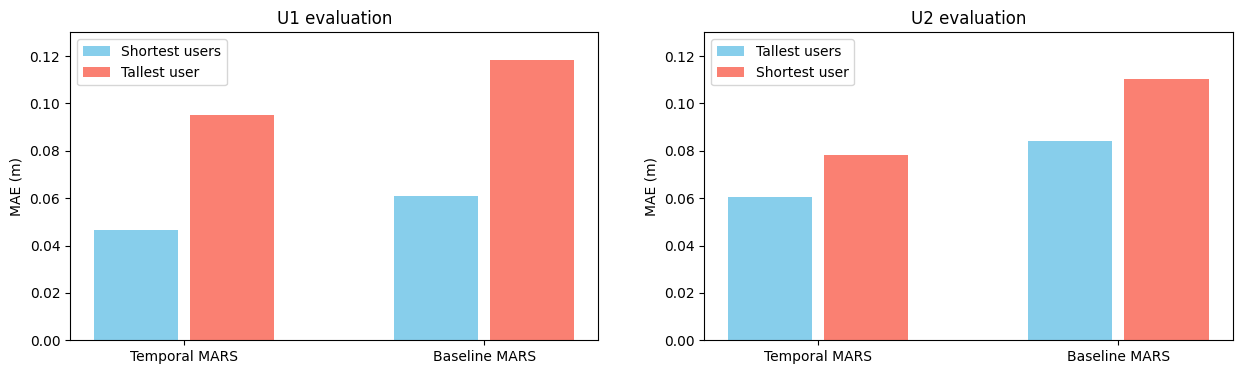

In [ ]:
# Plotting results
import json
import math
import os
import matplotlib.pyplot as plt



movements = {
    "A": "Lateral Right Arm",
    "B": "Lateral Left Arm",
    "C": "Lateral Combined Arms",
    "D": "Waving Right Arm",
    "E": "Waving Left Arm",
    "F": "Waving Combined"
}

distance = {
    "A": "2m",
    "B": "3m"
}

environments = {
    "A": "Penguin Lab",
    "B": "Common Room",
    "C": "Cluttered Room"
}

user = {
    "A": "1.83m ",
    "B": "1.65m",
    "C": "1.55m",
    "D": "1.77m"
}

RESULT_PATH = os.path.join("..", "main_val_results")

def read_json(filename):
    data = None
    with open(filename, "r") as f:
        data = json.loads(f.read())
    return data

def plot_single_result(train_vals, test_vals, exp, ax, train_label, test_label):
    max_y = 0.13
    
    left_bars = train_vals   # left bars in each group
    right_bars = test_vals  # right bars in each group

    # Positions
    left_positions = [0, 2.5]
    right_positions = [0.8, 3.3]

    # Plot left bars
    ax.bar(left_positions, left_bars, width=0.7, label=train_label, color='skyblue')

    # Plot right bars
    ax.bar(right_positions, right_bars, width=0.7, label=test_label, color='salmon')

    # X-axis group label positions and names
    group_label_positions = [
        (left_positions[0] + right_positions[0]) / 2,
        (left_positions[1] + right_positions[1]) / 2
    ]
    group_labels = ['Temporal MARS', 'Baseline MARS']

    # Set ticks and labels
    ax.set_xticks(group_label_positions, group_labels)
    ax.set_ylabel('MAE (m)')
    ax.set_ylim((0., max_y))
    ax.set_title(f'{exp} evaluation')
    ax.legend()




def run_plotting(experiment_type):
    files = os.listdir(RESULT_PATH)
    experiment_desc = read_json("generalisation_test_desc.json")
    # print(experiment_desc)
    experiment_result = {}
    for f in files:
        exp = f.split("_")
        if exp[0][0] != experiment_type[0]:
            continue
        if exp[1] == 'training':
            continue
        data = read_json(os.path.join(RESULT_PATH, f))
        experiment_result[exp[0]] = data

        # print(f"{exp[0]}: tmars: {round(data['tmars']['g'], 4)}, bmars: {round(data['bmars']['g'], 4)}")
    exp_list = list(experiment_result.keys())
    exp_count = len(exp_list)
    
    fig, axs = plt.subplots(1, exp_count + (1 if exp_count == 1 else 0), figsize=(15, 4))  # 1 row, 3 columns

    codes = []
    codes_label = {}
    codes_color = {}
    if experiment_type == "E":
        codes = list(environments.keys())
        codes_label = environments
    elif experiment_type == "A":
        codes = list(movements.keys())
        codes_label = movements
    elif experiment_type == "U":
        codes = list(user.keys())
        codes_label = user
    elif experiment_type == "D":
        codes = list(distance.keys())
        codes_label = distance
    print(codes, codes_label)

    train_codes = []
    test_codes = []
    for exp in exp_list:
        train_codes.append(experiment_desc[exp]['train_codes'])
        test_codes.append(list( set(codes) - set(experiment_desc[exp]['train_codes']) ))
    # for code in codes):
    #     codes_color[code]
    # print(train_codes)
    # print(test_codes)
    # max_y = 0.
    for i in range(exp_count):
        experiment = exp_list[i]
        train_c = train_codes[i]
        test_c = test_codes[i]
        exp_data = experiment_result[experiment]
        train_vals = [exp_data['tmars']['train_mae'], exp_data['bmars']['train_mae']]
        test_vals = [exp_data['tmars']['test_mae'], exp_data['bmars']['test_mae']]
        # max_y = [max_y, *train_vals, test_vals]
        train_label = "\n".join([codes_label[c] for c in train_c])
        test_label = "\n".join([codes_label[c] for c in test_c])
        if experiment == "A1":
            train_label = "Right + Left arm"
            test_label = "Combined arm"
        if experiment == "A2":
            train_label = "Right + Combined arm"
            test_label = "Left arm"
        if experiment == "A3":
            train_label = "Straight arm"
            test_label = "Waving arm"
        if experiment == "U1":
            train_label = "Shortest users"
            test_label = "Tallest user"
        if experiment == "U2":
            train_label = "Tallest users"
            test_label = "Shortest user"
        plot_single_result(train_vals,test_vals, experiment, axs[i], train_label, test_label)
        # axs[i].bar(x, y1, color='skyblue')
        # axs[i].set_title(f"{experiment}")
        # axs[i].set_xlabel("Item")
        # axs[i].set_ylabel("Quantity")


run_plotting("U")

{'tmars': {'g': 0.04644571378865638, 'test': {'mae': 0.05449332902114442, 'joint_mae': [0.013900352195410023, 0.03675448793901539, 0.08962564613942359, 0.06172144246505441, 0.022726933111981654, 0.022587833038803833, 0.04714167514411665, 0.08482934019542154, 0.176317971196372, 0.13747742959075682, 0.032965480626624376, 0.040752314803079066, 0.04963732103498422, 0.01453700512621573, 0.05207651466805816, 0.04495378992910969, 0.03426993340995474, 0.03814966533429879, 0.03494811545305616], 'euc': 0.11469418659164357, 'joint_euc': [0.03222577741380471, 0.08282417303738963, 0.20596484263857331, 0.1671851552519492, 0.04712180462173884, 0.042269872210131273, 0.09602717013873059, 0.15003030238062492, 0.3734300231501946, 0.28936199202648316, 0.06794785630678823, 0.08556770573940523, 0.10434222756209702, 0.030562235028467256, 0.10687366631528496, 0.0923637444974591, 0.06440992919339839, 0.07243632503420704, 0.06824474269449828]}, 'train': {'mae': 0.05251001413020244, 'joint_mae': [0.0168229311808

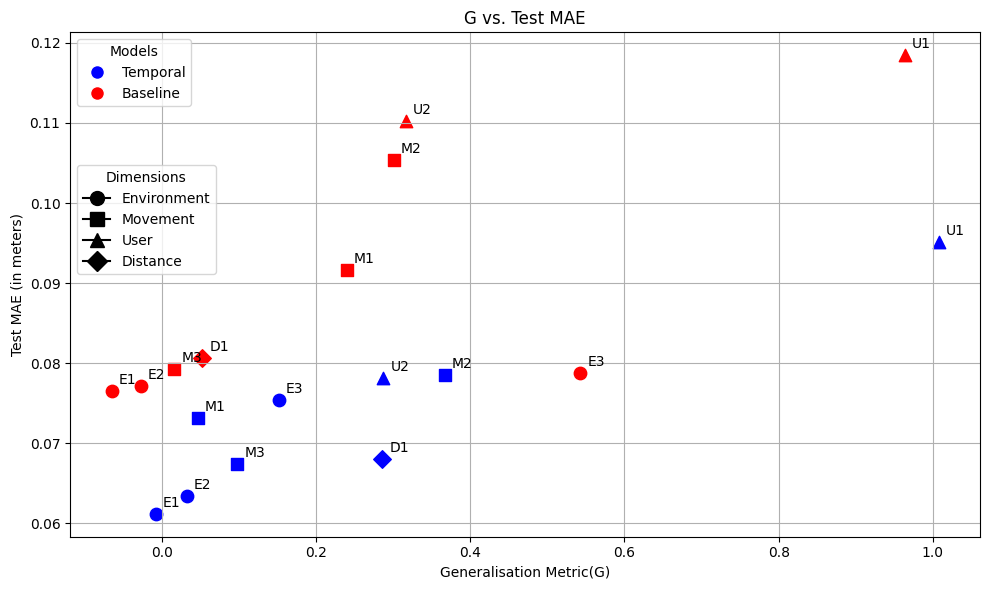

In [35]:
# Create the pareto chart
import json
import os


results = os.listdir(RESULT_PATH)

exp_res_tmars = {}
exp_res_bmars = {}
key = ['tmars', 'bmars']
for res in results:
    if '_training_' in res:
        continue
    data = load_json(os.path.join(RESULT_PATH, res))
    print(data)
    exp = res.split("_")[0]
    exp_res_tmars[exp] = {'g': data['tmars']['g'], 'mae': data['tmars']['test_mae']}
    exp_res_bmars[exp] = {'g': data['bmars']['g'], 'mae': data['bmars']['test_mae']}
    
print(exp_res_tmars)
print(exp_res_bmars)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

dim_markers = {
    'E': 'o',
    'A': 's',
    'U': '^',
    'D': 'D'
}

dim_labels = {
    'E': 'Environment',
    'A': 'Movement',
    'U': 'User',
    'D': 'Distance'
}
dimensions = ['E', 'A', 'U', 'D']
markers = ['o', 's', '^', 'D']
marker_labels = ['Environment', 'Movement', 'User','Distance']
color_labels = ['Temporal', 'Baseline']
colors = ['blue', 'red']
# Extract g and mae values
# exps = [e for e in exp_res_tmars.keys()]
g_values_tmars = [v['g'] for v in exp_res_tmars.values()]
mae_values_tmars = [v['mae'] for v in exp_res_tmars.values()]
labels_tmars = list(exp_res_tmars.keys())

g_values_bmars = [v['g'] for v in exp_res_bmars.values()]
mae_values_bmars = [v['mae'] for v in exp_res_bmars.values()]
labels_bmars = list(exp_res_bmars.keys())

plt.figure(figsize=(10, 6))
for i in range(len(labels_tmars)):
    mark = dim_markers[labels_tmars[i][0]]
    plt.scatter(g_values_tmars[i], mae_values_tmars[i], color = 'blue', marker=mark, s =80 )

for i in range(len(labels_bmars)):
    mark = dim_markers[labels_bmars[i][0]]
    # print(mark, label)
    plt.scatter(g_values_bmars[i], mae_values_bmars[i], color = 'red', marker=mark, s=80)

marker_handles = [
    Line2D([0], [0], marker=markers[i], color='black', label=marker_labels[i],
           markerfacecolor='black', markersize=10)
    for i in range(4)
]

color_handles = [
    Line2D([0], [0], marker='o', color='w', label=color_labels[i],
           markerfacecolor=colors[i], markersize=10)
    for i in range(2)
]

legend1 = plt.legend(handles=color_handles, title='Models', loc='upper left', bbox_to_anchor=(0, 1))
plt.gca().add_artist(legend1)  #

plt.legend(handles=marker_handles, title='Dimensions', loc='upper left', bbox_to_anchor=(0, 0.75))



# Create scatter plot
# plt.scatter(g_values_tmars, mae_values_tmars, color='blue')

# plt.scatter(g_values_bmars, mae_values_bmars, color='red')

# Annotate each point
for i in range(len(labels_tmars)):
    if labels_tmars[i][0] == "A":
        labels_tmars[i] = "M"+ labels_tmars[i][1]

for i in range(len(labels_bmars)):
    if labels_bmars[i][0] == "A":
        labels_bmars[i] = "M"+ labels_bmars[i][1]
        

for label, x, y in zip(labels_tmars, g_values_tmars, mae_values_tmars):
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(5, 5), ha='left')

for label, x, y in zip(labels_bmars, g_values_bmars, mae_values_bmars):
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(5, 5), ha='left')

# Labels and title
plt.xlabel('Generalisation Metric(G)')
plt.ylabel('Test MAE (in meters)')
plt.title('G vs. Test MAE')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


{'tmars': {'g': 0.04522781248019806, 'test': {'mae': 0.05449332902114442, 'joint_mae': [0.013900352195410023, 0.03675448793901539, 0.08962564613942359, 0.06172144246505441, 0.022726933111981654, 0.022587833038803833, 0.04714167514411665, 0.08482934019542154, 0.176317971196372, 0.13747742959075682, 0.032965480626624376, 0.040752314803079066, 0.04963732103498422, 0.01453700512621573, 0.05207651466805816, 0.04495378992910969, 0.03426993340995474, 0.03814966533429879, 0.03494811545305616], 'euc': 0.11469418659164357, 'joint_euc': [0.03222577741380471, 0.08282417303738963, 0.20596484263857331, 0.1671851552519492, 0.04712180462173884, 0.042269872210131273, 0.09602717013873059, 0.15003030238062492, 0.3734300231501946, 0.28936199202648316, 0.06794785630678823, 0.08556770573940523, 0.10434222756209702, 0.030562235028467256, 0.10687366631528496, 0.0923637444974591, 0.06440992919339839, 0.07243632503420704, 0.06824474269449828]}, 'train': {'mae': 0.05263991446043555, 'joint_mae': [0.0169014035147

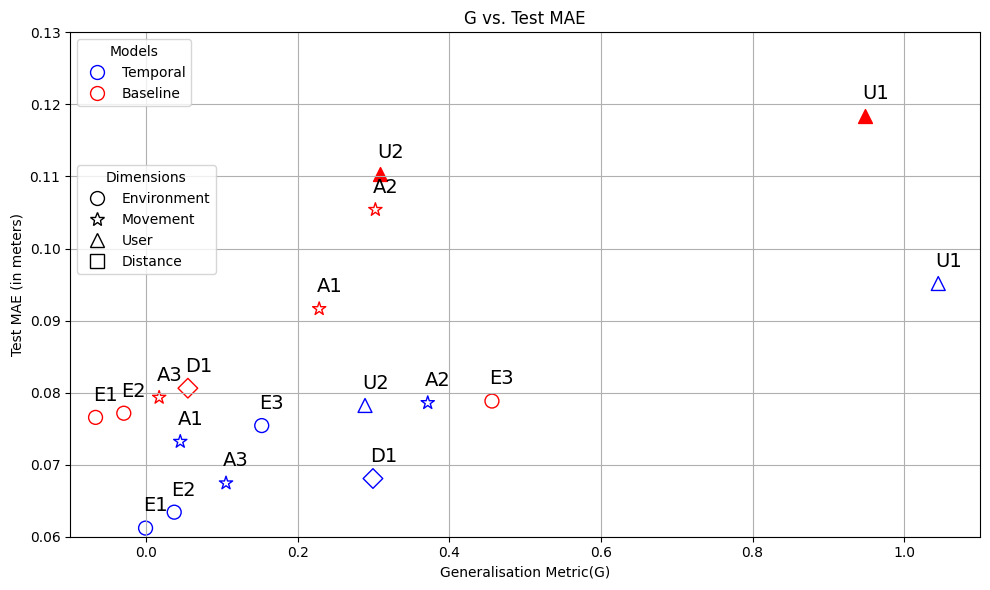

In [ ]:
import json
import os


results = os.listdir(RESULT_PATH)

exp_res_tmars = {}
exp_res_bmars = {}
key = ['tmars', 'bmars']
for res in results:
    if '_training_' in res:
        continue
    data = load_json(os.path.join(RESULT_PATH, res))
    print(data)
    exp = res.split("_")[0]
    exp_res_tmars[exp] = {'g': data['tmars']['g'], 'mae': data['tmars']['test_mae']}
    exp_res_bmars[exp] = {'g': data['bmars']['g'], 'mae': data['bmars']['test_mae']}
    
print(exp_res_tmars)
print(exp_res_bmars)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

unicode_markers = {
    'o': '●',  # Circle
    's': '■',  # Square
    '^': '▲',  # Triangle up
    'D': '◆'   # Diamond
}

dim_markers = {
    'E': 'o',  # Environment -> Circle
    'A': '*',  # Movement -> Star
    'U': '^',  # User -> Triangle up
    'D': 'D'   # Distance -> Diamond
}


# --- Data extraction (from your original script) ---
g_values_tmars = [v['g'] for v in exp_res_tmars.values()]
mae_values_tmars = [v['mae'] for v in exp_res_tmars.values()]
labels_tmars = list(exp_res_tmars.keys())

g_values_bmars = [v['g'] for v in exp_res_bmars.values()]
mae_values_bmars = [v['mae'] for v in exp_res_bmars.values()]
labels_bmars = list(exp_res_bmars.keys())


# --- PLOTTING CHANGES START HERE ---

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Use ax.scatter with 'facecolors' set to 'none' for hollow markers
# Plotting for tmars (blue outline)
for i in range(len(labels_tmars)):
    marker_style = dim_markers[labels_tmars[i][0]]
    if labels_tmars[i][0] != "U":

        ax.scatter(g_values_tmars[i], mae_values_tmars[i],
                marker=marker_style,
                facecolors='none',      # This makes the marker hollow
                edgecolors='blue',    # This sets the outline color
                s=100)                  # 's' controls the marker size
    else:
        ax.scatter(g_values_tmars[i], mae_values_tmars[i],
                marker=marker_style,
                facecolors='blue',      # This makes the marker hollow
                edgecolors='blue',    # This sets the outline color
                s=100)

# Plotting for bmars (red outline)
for i in range(len(labels_bmars)):
    marker_style = dim_markers[labels_bmars[i][0]]
    if labels_bmars[i][0] != "U":

        ax.scatter(g_values_bmars[i], mae_values_bmars[i],
               marker=marker_style,
               facecolors='none',      # This makes the marker hollow
               edgecolors='red',     # This sets the outline color
               s=100)                  # 's' controls the marker size
    else:
         ax.scatter(g_values_bmars[i], mae_values_bmars[i],
               marker=marker_style,
               facecolors='red',      # This makes the marker hollow
               edgecolors='red',     # This sets the outline color
               s=100)  


# --- Legend creation (updated for hollow markers) ---
markers = ['o', '*', '^', 's']
marker_labels = ['Environment', 'Movement', 'User','Distance']
color_labels = ['Temporal', 'Baseline']
colors = ['blue', 'red']

# Legend for marker shapes
marker_handles = [
    Line2D([0], [0], marker=markers[i], color='w', label=marker_labels[i],
           markerfacecolor='none',          # Hollow in legend
           markeredgecolor='black',         # Black outline in legend
           markersize=10)
    for i in range(len(markers))
]

# Legend for marker colors
color_handles = [
    Line2D([0], [0], marker='o', color='w', label=color_labels[i],
           markerfacecolor='none',          # Hollow in legend
           markeredgecolor=colors[i],       # Colored outline in legend
           markersize=10)
    for i in range(len(colors))
]

legend1 = ax.legend(handles=color_handles, title='Models', loc='upper left', bbox_to_anchor=(0, 1))
ax.add_artist(legend1)
ax.legend(handles=marker_handles, title='Dimensions', loc='upper left', bbox_to_anchor=(0, 0.75))

# --- Annotations and labels (no changes needed here) ---
# Annotate each point
for label, x, y in zip(labels_tmars, g_values_tmars, mae_values_tmars):
    # if label[0] == 
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(-2, 12), ha='left', fontsize=14)

for label, x, y in zip(labels_bmars, g_values_bmars, mae_values_bmars):
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(-2, 12), ha='left', fontsize=14)

# Labels and title
ax.set_xlabel('Generalisation Metric(G)')
ax.set_ylabel('Test MAE (in meters)')
ax.set_title('G vs. Test MAE')
ax.set_xlim((-0.1, 1.1))
ax.set_ylim(0.06, 0.13)
ax.grid(True)
fig.tight_layout()

# Save the plot
plt.savefig("hollow_marker_plot.png")

# Show the plot
# plt.show()